In [1]:
import os
os.environ['PATH'] = '/home/irman/Gelochip/.venv/bin:' + os.environ.get('PATH', '')
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, '/home/irman/Gelochip/src/gelochip')

import klayout.db as kdb
import klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))




2026-05-18 19:31:46.083 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.



2026-05-18 19:31:46.613 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/generic_tech/layer_views.yaml'.


2026-05-18 19:31:46.615 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active


2026-05-18 19:31:46.623 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


/tmp/ipykernel_18844/4271619226.py:292: UserWarning: Unnamed cells, 15 in 'Unnamed_d8af3f3a'
  comp.write_gds("opamp_twostage.gds")
2026-05-18 19:32:29.556 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'opamp_twostage.gds'


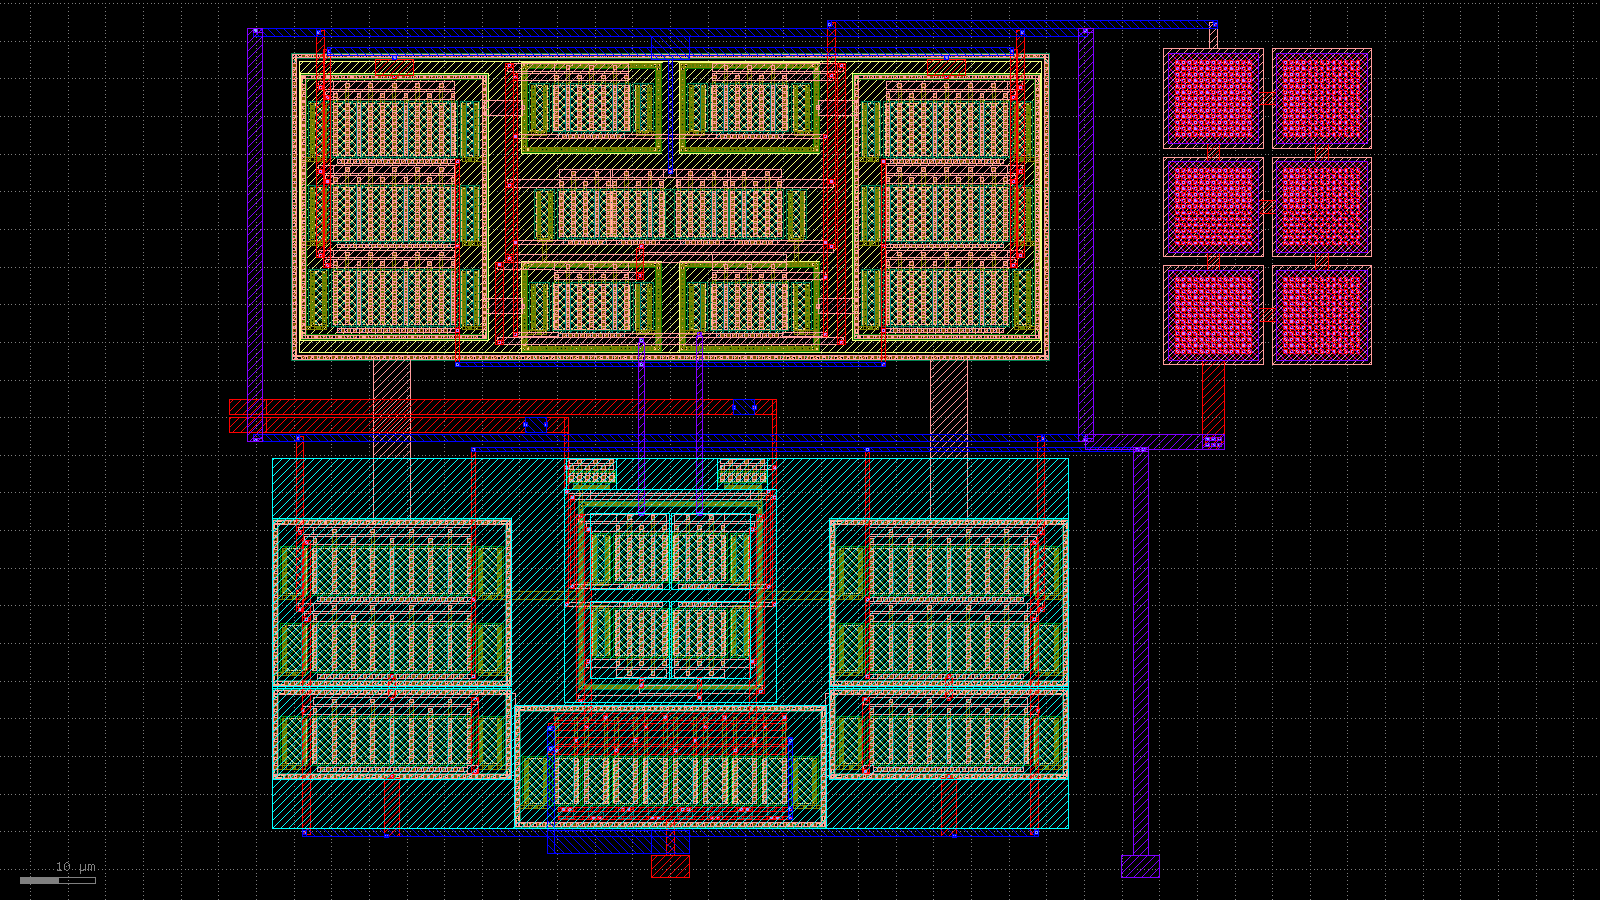

/home/irman/Gelochip/src/gelochip/glayout/pdk/mappedpdk.py:538: UserWarning: Unnamed cells, 14 in 'opamp_twostage'
  layout.write_gds(gds_path)
2026-05-18 19:32:29.665 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpoxlfjvol/opamp_twostage.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl


/home/irman/Gelochip/src/gelochip/glayout/pdk/mappedpdk.py:762: UserWarning: Unnamed cells, 14 in 'opamp_twostage'
  layout.write_gds(str(gds_path))
2026-05-18 19:32:30.118 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpxns_y007/opamp_twostage.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpoxlfjvol/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "opamp_twostage".
Reading "c_rou


Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "opamp_twostage".
Reading "c_route_1e4dd

In [2]:
import sys
try:
    cm_mod = sys.modules['glayout.cells.elementary.current_mirror.current_mirror']
    if not hasattr(cm_mod, 'orig_cmn'):
        orig_cmn = cm_mod.current_mirror_netlist
        cm_mod.orig_cmn = orig_cmn
        def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
            netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
            if 'B' in netlist.nodes:
                idx = netlist.nodes.index('B')
                netlist.nodes[idx] = 'VB'
            if 'VOUT' in netlist.nodes:
                idx = netlist.nodes.index('VOUT')
                netlist.nodes[idx] = 'VCOPY'
            return netlist
        cm_mod.current_mirror_netlist = patched_cmn
        for modname, mod in list(sys.modules.items()):
            if hasattr(mod, 'current_mirror_netlist'):
                setattr(mod, 'current_mirror_netlist', patched_cmn)
except Exception as e:
    pass

from gdsfactory.cell import cell, clear_cache
from gdsfactory.component import Component, copy
from gdsfactory.component_reference import ComponentReference
from gdsfactory.components.rectangle import rectangle
from glayout.pdk.mappedpdk import MappedPDK
from typing import Optional, Union
from glayout.primitives.fet import nmos, pmos, multiplier
from glayout.cells.elementary.diff_pair import diff_pair
from glayout.primitives.guardring import tapring
from glayout.primitives.mimcap import mimcap_array, mimcap
from glayout.routing.L_route import L_route
from glayout.routing.c_route import c_route
from glayout.primitives.via_gen import via_stack, via_array
from gdsfactory.routing.route_quad import route_quad
from glayout.util.comp_utils import evaluate_bbox, prec_ref_center, movex, movey, to_decimal, to_float, move, align_comp_to_port, get_padding_points_cc
from glayout.util.port_utils import rename_ports_by_orientation, rename_ports_by_list, add_ports_perimeter, print_ports, set_port_orientation, rename_component_ports
from glayout.routing.straight_route import straight_route
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.placement.two_transistor_interdigitized import two_nfet_interdigitized

from glayout.cells.composite.diffpair_cmirror_bias import diff_pair_ibias
from glayout.cells.composite.stacked_current_mirror import stacked_nfet_current_mirror
from glayout.cells.composite.differential_to_single_ended_converter import differential_to_single_ended_converter
from glayout.cells.composite.opamp.row_csamplifier_diff_to_single_ended_converter import row_csamplifier_diff_to_single_ended_converter
from glayout.cells.composite.opamp.diff_pair_stackedcmirror import diff_pair_stackedcmirror
from glayout.spice import Netlist
from glayout.cells.elementary.current_mirror import current_mirror_netlist

# Patch to add fingers=1 default and rename nodes B->VB, VOUT->VCOPY
import sys as _sys
_cm_mod = _sys.modules.get('glayout.cells.elementary.current_mirror.current_mirror')
_dcm_mod = _sys.modules.get('glayout.cells.composite.diffpair_cmirror_bias.diff_pair_cmirrorbias')
if _cm_mod and not hasattr(_cm_mod, '_patched'):
    _orig_cmn = _cm_mod.current_mirror_netlist
    def _pcmn(pdk, width, length, multipliers, fingers=1, **kwargs):
        nl = _orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
        if 'B' in nl.nodes: nl.nodes[nl.nodes.index('B')] = 'VB'
        if 'VOUT' in nl.nodes: nl.nodes[nl.nodes.index('VOUT')] = 'VCOPY'
        return nl
    _cm_mod.current_mirror_netlist = _pcmn
    _cm_mod._patched = True
if _cm_mod and _dcm_mod:
    _dcm_mod.current_mirror_netlist = _cm_mod.current_mirror_netlist
    current_mirror_netlist = _cm_mod.current_mirror_netlist

def __create_and_route_pins(
    pdk: MappedPDK,
    opamp_top: Component,
    pmos_comps_ref: ComponentReference,
    halfmultn_drain_routeref: ComponentReference,
    halfmultn_gate_routeref: ComponentReference
) -> tuple:
    _max_metal_seperation_ps = pdk.util_max_metal_seperation()
    # route halfmultp source, drain, and gate together, place vdd pin in the middle
    halfmultp_Lsrcport = opamp_top.ports["commonsource_Pamp_L_multiplier_0_source_con_N"]
    halfmultp_Rsrcport = opamp_top.ports["commonsource_Pamp_R_multiplier_0_source_con_N"]
    opamp_top << c_route(pdk, halfmultp_Lsrcport, halfmultp_Rsrcport, extension=opamp_top.ymax-halfmultp_Lsrcport.center[1], fullbottom=True,viaoffset=(False,False))
    # place vdd pin
    vddpin = opamp_top << rectangle(size=(5,3),layer=pdk.get_glayer("met4"),centered=True)
    vddpin.movey(opamp_top.ymax)
    # route vdd to source of 2L/2R
    opamp_top << straight_route(pdk, opamp_top.ports["pcomps_2L2Rsrcvia_top_met_N"], vddpin.ports["e4"])
    # drain route above vdd pin
    halfmultp_Ldrainport = opamp_top.ports["commonsource_Pamp_L_multiplier_0_drain_con_N"]
    halfmultp_Rdrainport = opamp_top.ports["commonsource_Pamp_R_multiplier_0_drain_con_N"]
    halfmultp_drain_routeref = opamp_top << c_route(pdk, halfmultp_Ldrainport, halfmultp_Rdrainport, extension=opamp_top.ymax-halfmultp_Ldrainport.center[1]+pdk.get_grule("met5")["min_separation"], fullbottom=True)
    halfmultp_Lgateport = opamp_top.ports["commonsource_Pamp_L_multiplier_0_gate_con_S"]
    halfmultp_Rgateport = opamp_top.ports["commonsource_Pamp_R_multiplier_0_gate_con_S"]
    ptop_halfmultp_gate_route = opamp_top << c_route(pdk, halfmultp_Lgateport, halfmultp_Rgateport, extension=abs(pmos_comps_ref.ymin-halfmultp_Lgateport.center[1])+pdk.get_grule("met5")["min_separation"],fullbottom=True,viaoffset=(False,False))
    # halfmultn to halfmultp drain to drain route
    extensionL = min(halfmultn_drain_routeref.ports["con_W"].center[0],halfmultp_drain_routeref.ports["con_W"].center[0])
    extensionR = max(halfmultn_drain_routeref.ports["con_E"].center[0],halfmultp_drain_routeref.ports["con_E"].center[0])
    opamp_top << c_route(pdk, halfmultn_drain_routeref.ports["con_W"], halfmultp_drain_routeref.ports["con_W"],extension=abs(opamp_top.xmin-extensionL)+2,cwidth=2)
    n_to_p_output_route = opamp_top << c_route(pdk, halfmultn_drain_routeref.ports["con_E"], halfmultp_drain_routeref.ports["con_E"],extension=abs(opamp_top.xmax-extensionR)+2,cwidth=2)
    # top nwell taps to vdd, top p substrate taps to gnd
    opamp_top << straight_route(pdk, opamp_top.ports["commonsource_cmirror_output_L_tie_N_top_met_N"], opamp_top.ports["pcomps_top_ptap_S_top_met_S"], width=5)
    opamp_top << straight_route(pdk, opamp_top.ports["commonsource_cmirror_output_R_tie_N_top_met_N"], opamp_top.ports["pcomps_top_ptap_S_top_met_S"], width=5)
    L_toptapn_route = opamp_top.ports["commonsource_Pamp_L_tie_N_top_met_N"]
    R_toptapn_route = opamp_top.ports["commonsource_Pamp_R_tie_N_top_met_N"]
    opamp_top << straight_route(pdk, movex(vddpin.ports["e4"],destination=L_toptapn_route.center[0]), L_toptapn_route, glayer1="met3",fullbottom=True)
    opamp_top << straight_route(pdk, movex(vddpin.ports["e4"],destination=R_toptapn_route.center[0]), R_toptapn_route, glayer1="met3",fullbottom=True)
    # bias pins for first two stages
    vbias1 = opamp_top << rectangle(size=(5,3),layer=pdk.get_glayer("met3"),centered=True)
    vbias1.movey(opamp_top.ymin - _max_metal_seperation_ps - vbias1.ymax)
    opamp_top << straight_route(pdk, vbias1.ports["e2"], opamp_top.ports["diffpair_ibias_B_gate_S"],width=1,fullbottom=False)
    vbias2 = opamp_top << rectangle(size=(5,3),layer=pdk.get_glayer("met5"),centered=True)
    vbias2.movex(1+opamp_top.xmax+evaluate_bbox(vbias2)[0]+pdk.util_max_metal_seperation()).movey(opamp_top.ymin+vbias2.ymax)
    opamp_top << L_route(pdk, halfmultn_gate_routeref.ports["con_E"], vbias2.ports["e2"],hwidth=2)
    # route + and - pins (being careful about antenna violations)
    minusi_pin = opamp_top << rectangle(size=(5,2),layer=pdk.get_glayer("met3"),centered=True)
    minusi_pin.movex(opamp_top.xmin).movey(_max_metal_seperation_ps + minusi_pin.ymax + halfmultn_drain_routeref.ports["con_W"].center[1] + halfmultn_drain_routeref.ports["con_W"].width/2)
    iport_antenna1 = movex(minusi_pin.ports["e3"],destination=opamp_top.ports["diffpair_MINUSgateroute_W_con_N"].center[0]-9*_max_metal_seperation_ps)
    opamp_top << L_route(pdk, opamp_top.ports["diffpair_MINUSgateroute_W_con_N"],iport_antenna1)
    iport_antenna2 = movex(iport_antenna1,offsetx=-9*_max_metal_seperation_ps)
    opamp_top << straight_route(pdk, iport_antenna1, iport_antenna2,glayer1="met4",glayer2="met4",via2_alignment=('c','c'),via1_alignment=('c','c'),fullbottom=True)
    iport_antenna2.layer=pdk.get_glayer("met4")
    opamp_top << straight_route(pdk, iport_antenna2, minusi_pin.ports["e3"],glayer1="met3",via2_alignment=('c','c'),via1_alignment=('c','c'),fullbottom=True)
    plusi_pin = opamp_top << rectangle(size=(5,2),layer=pdk.get_glayer("met3"),centered=True)
    plusi_pin.movex(opamp_top.xmin + plusi_pin.xmax).movey(_max_metal_seperation_ps + minusi_pin.ymax + plusi_pin.ymax)
    iport_antenna1 = movex(plusi_pin.ports["e3"],destination=opamp_top.ports["diffpair_PLUSgateroute_E_con_N"].center[0]-9*_max_metal_seperation_ps)
    opamp_top << L_route(pdk, opamp_top.ports["diffpair_PLUSgateroute_E_con_N"],iport_antenna1)
    iport_antenna2 = movex(iport_antenna1,offsetx=-9*_max_metal_seperation_ps)
    opamp_top << straight_route(pdk, iport_antenna1, iport_antenna2, glayer1="met4",glayer2="met4",via2_alignment=('c','c'),via1_alignment=('c','c'),fullbottom=True)
    iport_antenna2.layer=pdk.get_glayer("met4")
    opamp_top << straight_route(pdk, iport_antenna2, plusi_pin.ports["e3"],glayer1="met3",via2_alignment=('c','c'),via1_alignment=('c','c'),fullbottom=True)
    # route top center components to diffpair
    opamp_top << straight_route(pdk,opamp_top.ports["diffpair_tr_multiplier_0_drain_N"], opamp_top.ports["pcomps_pbottomAB_R_gate_S"], glayer1="met5",width=3*pdk.get_grule("met5")["min_width"],via1_alignment_layer="met2",via1_alignment=('c','c'))
    opamp_top << straight_route(pdk,opamp_top.ports["diffpair_tl_multiplier_0_drain_N"], opamp_top.ports["pcomps_minusvia_top_met_S"], glayer1="met5",width=3*pdk.get_grule("met5")["min_width"],via1_alignment_layer="met2",via1_alignment=('c','c'))
    # route minus transistor drain to output
    outputvia_diff_pcomps = opamp_top << via_stack(pdk,"met5","met4")
    outputvia_diff_pcomps.movex(opamp_top.ports["diffpair_tl_multiplier_0_drain_N"].center[0]).movey(ptop_halfmultp_gate_route.ports["con_E"].center[1])
    # add pin ports
    opamp_top.add_ports(vddpin.get_ports_list(), prefix="pin_vdd_")
    opamp_top.add_ports(vbias1.get_ports_list(), prefix="pin_diffpairibias_")
    opamp_top.add_ports(vbias2.get_ports_list(), prefix="pin_commonsourceibias_")
    opamp_top.add_ports(minusi_pin.get_ports_list(), prefix="pin_minus_")
    opamp_top.add_ports(plusi_pin.get_ports_list(), prefix="pin_plus_")
    #opamp_top.add_ports(output.get_ports_list(), prefix="pin_output_")
    return opamp_top, n_to_p_output_route



def __add_mimcap_arr(pdk: MappedPDK, opamp_top: Component, mim_cap_size, mim_cap_rows, ymin: float, n_to_p_output_route) -> tuple[Component, Netlist]:
    mim_cap_size = pdk.snap_to_2xgrid(mim_cap_size, return_type="float")
    max_metalsep = pdk.util_max_metal_seperation()
    mimcaps_ref = opamp_top << mimcap_array(pdk,mim_cap_rows,2,size=mim_cap_size,rmult=6)
    if int(mim_cap_rows) < 1:
        raise ValueError("mim_cap_rows should be a positive integer")
    mimcap_netlist = mimcaps_ref.info['netlist']

    displace_fact = max(max_metalsep,pdk.get_grule("capmet")["min_separation"])
    mimcaps_ref.movex(pdk.snap_to_2xgrid(opamp_top.xmax + displace_fact + mim_cap_size[0]/2))
    mimcaps_ref.movey(pdk.snap_to_2xgrid(ymin + mim_cap_size[1]/2))
    # connect mimcap to gnd
    port1 = opamp_top.ports["pcomps_mimcap_connection_con_N"]
    port2 = mimcaps_ref.ports["row"+str(int(mim_cap_rows)-1)+"_col0_bottom_met_N"]
    cref2_extension = max_metalsep + opamp_top.ymax - max(port1.center[1], port2.center[1])
    opamp_top << c_route(pdk,port1,port2, extension=cref2_extension, fullbottom=True)
    intermediate_output = set_port_orientation(n_to_p_output_route.ports["con_S"],"E")
    opamp_top << L_route(pdk, mimcaps_ref.ports["row0_col0_top_met_S"], intermediate_output, hwidth=3)
    opamp_top.add_ports(mimcaps_ref.get_ports_list(),prefix="mimcap_")
    # add the cs output as a port
    opamp_top.add_port(name="commonsource_output_E", port=intermediate_output)
    return opamp_top, mimcap_netlist

def opamp_gain_stage_netlist(mimcap_netlist: Netlist, diff_cs_netlist: Netlist, cs_bias_netlist: Netlist) -> Netlist:
    netlist = Netlist(
        circuit_name="GAIN_STAGE",
        nodes=['VIN1', 'VIN2', 'VOUT', 'VDD', 'IBIAS', 'GND']
    )

    diff_cs_ref = netlist.connect_netlist(
        diff_cs_netlist,
        [('VSS', 'VDD')]
    )

    netlist.connect_netlist(
        cs_bias_netlist,
        [('VREF', 'IBIAS'), ('VSS', 'GND'), ('VCOPY', 'VOUT'), ('VB', 'GND')]
    )

    mimcap_ref = netlist.connect_netlist(mimcap_netlist, [('V1', 'VOUT'), ('V2', 'VSS2')])

    netlist.connect_subnets(
        mimcap_ref,
        diff_cs_ref,
        [('V2', 'VSS2')]
    )

    return netlist

def opamp_twostage_netlist(input_stage_netlist: Netlist, gain_stage_netlist: Netlist) -> Netlist:
    two_stage_netlist = Netlist(
        circuit_name="OPAMP_TWO_STAGE",
        nodes=['VDD', 'GND', 'DIFFPAIR_BIAS', 'VP', 'VN', 'CS_BIAS', 'VOUT']
    )

    input_stage_ref = two_stage_netlist.connect_netlist(
        input_stage_netlist,
        [('IBIAS', 'DIFFPAIR_BIAS'), ('VSS', 'GND'), ('B', 'GND')]
    )

    gain_stage_ref = two_stage_netlist.connect_netlist(
        gain_stage_netlist,
        [('IBIAS', 'CS_BIAS')]
    )

    two_stage_netlist.connect_subnets(
        input_stage_ref,
        gain_stage_ref,
        [('VDD1', 'VIN1'), ('VDD2', 'VIN2')]
    )

    return two_stage_netlist

def opamp_twostage(
    pdk: MappedPDK,
    half_diffpair_params: tuple[float, float, int] = (6, 1, 4),
    diffpair_bias: tuple[float, float, int] = (6, 2, 4),
    half_common_source_params: tuple[float, float, int, int] = (7, 1, 10, 3),
    half_common_source_bias: tuple[float, float, int, int] = (6, 2, 8, 2),
    half_pload: tuple[float,float,int] = (6,1,6),
    mim_cap_size=(12, 12),
    mim_cap_rows=3,
    rmult: int = 2,
    with_antenna_diode_on_diffinputs: int=5
) -> Component:
    """
    create a two stage opamp, args->
    pdk: pdk to use
    half_diffpair_params: diffpair (width,length,fingers)
    diffpair_bias: bias transistor for diffpair nmos (width,length,fingers). The ref and output of the cmirror are identical
    half_common_source_params: pmos top component amp (width,length,fingers,mults)
    half_common_source_bias: bottom L/R large nmos current mirror (width,length,fingers,mults). The ref of the cmirror always has 1 multplier. multiplier must be >=2
    ****NOTE: change the multiplier option to change the relative sizing of the current mirror ref/output
    half_pload: all 4 pmos load transistors of first stage (width,length,...). The last element in the tuple is the fingers of the bottom two pmos.
    mim_cap_size: width,length of individual mim_cap
    mim_cap_rows: number of rows in the mimcap array (always 2 cols)
    rmult: routing multiplier (larger = wider routes)
    with_antenna_diode_on_diffinputs: adds antenna diodes with_antenna_diode_on_diffinputs*(1um/0.5um) on the positive and negative inputs to the opamp
    """
    # error checks
    if with_antenna_diode_on_diffinputs!=0 and with_antenna_diode_on_diffinputs<2:
        raise ValueError("number of antenna diodes should be at least 2 (or 0 to specify no diodes)")
    if half_common_source_bias[3] < 2:
        raise ValueError("half_common_source_bias num multiplier must be >= 2")
    opamp_top, halfmultn_drain_routeref, halfmultn_gate_routeref, _cref = diff_pair_stackedcmirror(pdk, half_diffpair_params, diffpair_bias, half_common_source_bias, rmult, with_antenna_diode_on_diffinputs)

    opamp_top.info['netlist'].circuit_name = "INPUT_STAGE"

    # place pmos components
    pmos_comps = differential_to_single_ended_converter(pdk, rmult, half_pload, opamp_top.ports["diffpair_tl_multiplier_0_drain_N"].center[0])
    clear_cache()

    pmos_comps = row_csamplifier_diff_to_single_ended_converter(pdk, pmos_comps, half_common_source_params, rmult)

    cs_bias_netlist = current_mirror_netlist(
        pdk,
        width=diffpair_bias[0],
        length=diffpair_bias[1],
        fingers=1,
        multipliers=diffpair_bias[2]
    )

    ydim_ncomps = opamp_top.ymax
    pmos_comps_ref = opamp_top << pmos_comps
    pmos_comps_ref.movey(round(ydim_ncomps + pmos_comps_ref.ymax+10))
    opamp_top.add_ports(pmos_comps_ref.get_ports_list(),prefix="pcomps_")
    rename_func = lambda name_, port_ : name_.replace("pcomps_halfpspecialmarker","commonsource_Pamp") if name_.startswith("pcomps_halfpspecialmarker") else name_
    opamp_top = rename_component_ports(opamp_top, rename_function=rename_func)
    # create pins and route
    clear_cache()
    opamp_top, n_to_p_output_route = __create_and_route_pins(pdk, opamp_top, pmos_comps_ref, halfmultn_drain_routeref, halfmultn_gate_routeref)
    # place mimcaps and route
    clear_cache()
    opamp_top, mimcap_netlist = __add_mimcap_arr(pdk, opamp_top, mim_cap_size, mim_cap_rows, pmos_comps_ref.ymin, n_to_p_output_route)
    opamp_top.add_ports(n_to_p_output_route.get_ports_list(),"special_con_npr_")
    # return
    opamp_top.add_ports(_cref.get_ports_list(), prefix="gnd_route_")

    pmos_comps.info['netlist'] = opamp_gain_stage_netlist(mimcap_netlist, pmos_comps.info['netlist'], cs_bias_netlist)
    opamp_top.info['netlist'] = opamp_twostage_netlist(opamp_top.info['netlist'], pmos_comps.info['netlist'])

    return opamp_top



from glayout.pdk.gf180_mapped import gf180_mapped_pdk
comp = opamp_twostage(gf180_mapped_pdk)
comp.write_gds("opamp_twostage.gds")
show_gds("opamp_twostage.gds")

comp.name = 'opamp_twostage'
# DRC with magic (graceful if magic not installed)
try:
    drc_result = gf180_mapped_pdk.drc_magic(comp, comp.name)
    print('DRC:', drc_result)
except Exception as e:
    print(f'DRC skipped: {e}')
# LVS with netgen (graceful if netgen not installed)
try:
    lvs_result = gf180_mapped_pdk.lvs_netgen(comp, comp.name)
    print('LVS:', lvs_result['result_str'])
except Exception as e:
    print(f'LVS skipped: {e}')


In [3]:
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

if run_evaluation is not None:
    result = run_evaluation("opamp_twostage.gds", comp.name, comp)
    print(result)


--- Starting Comprehensive Evaluation for opamp_twostage ---
Cleaning up intermediate files for component 'opamp_twostage'...
  - Deleted: opamp_twostage.res.ext
  - Deleted directory: opamp_twostage_lvs_out
  - Deleted: opamp_twostage.nodes
Running verification checks (DRC, LVS)...
using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 19:32:38.665 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpexogev39/opamp_twostage.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmptmgcfhsp/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "Unnamed_d8af3f3a".
Reading "c_r


Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Using technology "gf180mcuD", version 1.0.493-0-g0fe599b
Library written using GDS-II Release 6.0
Library name: library
Reading "opamp_twostage".
Reading "c_route_1e4dd

--- Evaluation complete. Results saved to opamp_twostage_1.json ---
{'component_name': 'opamp_twostage', 'timestamp': '2026-05-18T19:33:05.482660', 'drc_lvs_fail': True, 'drc': {'status': 'pass', 'is_pass': True, 'report_path': '/home/irman/Gelochip/notebooks/datasets/opamp_twostage/opamp_twostage_drc_out/drc/opamp_twostage/opamp_twostage.rpt', 'summary': {'is_pass': True, 'total_errors': 0, 'error_details': []}}, 'lvs': {'status': 'fail', 'is_pass': False, 'report_path': '/home/irman/Gelochip/notebooks/datasets/opamp_twostage/opamp_twostage_lvs_out/lvs/opamp_twostage/opamp_twostage_lvs.rpt', 'summary': {'is_pass': False, 'conclusion': 'LVS Fail: Netlist mismatch.', 'total_mismatches': 0, 'mismatch_details': {'nets': '6 **Mismatch**             |Number of nets: 16 **Mismatch**', 'devices': '10 **Mismatch**         |Number of devices: 23 **Mismatch**', 'unmatched_nets_parsed': [], 'unmatched_instances_parsed': []}}}, 'pex': {'status': 'PEX Complete', 'total_resistance_ohms': 0.0, 'total

In [4]:
# ── SPICE Simulation with gf180 PDK models ─────────────────────────────────
import subprocess, os, re, tempfile

_GF180_MODELS = '/home/irman/Gelochip/src/gelochip/glayout/spice/gf180_typical.spice'

class _StringNetlist:
    def __init__(self, spice_str):
        import re as _re
        self._spice = spice_str
        # Use the LAST .subckt definition (top-level circuit)
        matches = list(_re.finditer(r'\.subckt\s+(\w+)\s+(.*)', spice_str, _re.IGNORECASE))
        if matches:
            m = matches[-1]
            self.circuit_name = m.group(1)
            # Filter out parameter-style tokens (containing =)
            self.nodes = [n for n in m.group(2).split() if '=' not in n]
        else:
            self.circuit_name = 'UNKNOWN'; self.nodes = []
    def generate_netlist(self): return self._spice

def _get_netlist(comp):
    if not hasattr(comp, 'info'): return None
    nl = comp.info.get('netlist_obj')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    nl = comp.info.get('netlist')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    if isinstance(nl, str) and nl.strip(): return _StringNetlist(nl)
    return None

def _fix_spice(spice):
    spice = re.sub(r'm=\{(\d+)\}', lambda x: f'm={x.group(1)}', spice)
    # Resolve l={expr}/w={expr} parameter placeholders to defaults
    spice = re.sub(r'\bl=\{[^}]+\}', 'l=0.28', spice)
    spice = re.sub(r'\bw=\{[^}]+\}', 'w=0.28', spice)
    # Clamp l/w to gf180 minimum valid values (in µm) to stay within model bins
    def _clamp_l(m):
        try: v = float(m.group(1)); return f'l={max(v, 0.28)}'
        except: return m.group(0)
    def _clamp_w(m):
        try: v = float(m.group(1)); return f'w={max(v, 0.22)}'
        except: return m.group(0)
    spice = re.sub(r'\bl=([\d.]+)', _clamp_l, spice)
    spice = re.sub(r'\bw=([\d.]+)', _clamp_w, spice)
    # Remove mimcap lines (not in gf180 model file)
    spice = re.sub(r'^.*mimcap.*$', '* mimcap removed', spice, flags=re.MULTILINE | re.IGNORECASE)
    return spice

def _build_testbench(name, nodes, vdd=3.3):
    nmap = {}
    for n in nodes:
        u = n.upper()
        if u in ('VDD', 'AVDD', 'VCC'): nmap[n] = 'vdd'
        elif u in ('VSS', 'GND', 'AVSS'): nmap[n] = '0'
        elif u in ('VB', 'VBULK', 'BULK', 'B'): nmap[n] = '0'
        else: nmap[n] = f'n_{n.lower()}'
    lines = [f'VDD vdd 0 DC {vdd}V']
    for n in nodes:
        u, c = n.upper(), nmap[n]
        if c in ('vdd', '0'): continue
        if any(k in u for k in ('INP', 'VINP', 'VP')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.55:.3f}')
        elif any(k in u for k in ('INM', 'VINM', 'VN')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.45:.3f}')
        elif any(k in u for k in ('IBIAS','NBC_','NB_10U','NB_','BIAS','DIFFPAIR_BIAS','CS_BIAS')):
            lines.append(f'I_{n} vdd {c} DC 10u')
        elif u == 'VREF':
            lines.append(f'Iref_{n} vdd {c} DC 10u')
        elif u in ('VOUT','OUTPUT','OUT','CSOUTPUT') or u.startswith('VOUT'):
            lines.append(f'RL_{n} vdd {c} 100k')
        elif u == 'VIN':
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
        elif u == 'VGN':
            lines.append(f'V_{n} {c} 0 DC {vdd:.3f}')
        elif u == 'VGP':
            lines.append(f'V_{n} {c} 0 DC 0')
        else:
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
    inst = ' '.join(nmap[n] for n in nodes)
    lines += [f'XDUT {inst} {name}', '.op',
              '.options GMIN=1e-12 RELTOL=1e-3 ITL1=500', '.save all']
    return '\n'.join(lines)

def run_spice_gf180(comp, label=''):
    nl = _get_netlist(comp)
    if nl is None:
        print(f'No netlist in {label or "component"}.info')
        return
    spice = _fix_spice(nl.generate_netlist())
    name = nl.circuit_name
    nodes = list(nl.nodes)
    print(f'Circuit : {name}')
    print(f'Nodes   : {nodes}')
    tb = _build_testbench(name, nodes)
    full = f'* {label or name}\n.include "{_GF180_MODELS}"\n\n{spice}\n\n{tb}\n.end\n'
    with tempfile.NamedTemporaryFile(mode='w', suffix='.sp', delete=False, dir='/tmp') as f:
        f.write(full); sp = f.name
    out_f = sp + '.out'
    try:
        r = subprocess.run(['ngspice', '-b', '-o', out_f, sp],
                           capture_output=True, text=True, timeout=60)
        raw = open(out_f).read() if os.path.exists(out_f) else r.stdout + r.stderr
        print(f'\n── DC Operating Point: {label or name} ──')
        in_tbl = False
        for line in raw.split('\n'):
            l = line.strip()
            if re.match(r'node\b.*voltage', l, re.I): in_tbl = True; print(f'\n{line}')
            elif in_tbl and re.match(r'-{3,}', l): print(line)
            elif in_tbl and not l: in_tbl = False
            elif in_tbl: print(line)
        no_conv = 'no convergence' in raw.lower()
        if r.returncode == 0 and not no_conv:
            print('\n\u2713 Converged \u2013 gf180 typical corner')
        elif no_conv:
            print('\n\u26a0 No convergence')
        else:
            errs = [l for l in raw.split('\n') if 'error' in l.lower() and l.strip()]
            print(f'\n\u26a0 ngspice exit {r.returncode}')
            for e in errs[:3]: print(f'  {e}')
    except Exception as e:
        print(f'Simulation error: {e}')
    finally:
        for fn in [sp, out_f]:
            try: os.unlink(fn)
            except: pass

run_spice_gf180(comp, label='opamp_twostage')


Circuit : OPAMP_TWO_STAGE
Nodes   : ['VDD', 'GND', 'DIFFPAIR_BIAS', 'VP', 'VN', 'CS_BIAS', 'VOUT']

── DC Operating Point: opamp_twostage ──

	Node                                  Voltage
	----                                  -------
	----	-------
	xdut.x1.x1.vout                  5.017446e-09
	xdut.x1.x1.b                     7.163730e-02
	xdut.x1.wire0                    3.285416e+00
	xdut.x1.x0.x0.v1                 3.273445e+00
	xdut.x0.x1.vout                  5.017446e-09
	xdut.x0.x1.b                     7.163730e-02
	xdut.wire1                       3.268150e+00
	xdut.x0.wire0                    1.240491e+00
	xdut.wire0                       2.986143e+00
	n_vout                           3.300000e+00
	n_cs_bias                        7.122403e-01
	n_vn                             1.485000e+00
	n_vp                             1.815000e+00
	n_diffpair_bias                  7.122403e-01
	vdd                              3.300000e+00

✓ Converged – gf180 typical corner
